Số lượng mẫu sau khi làm sạch: 25922
Số lượng biến đầu vào: 14


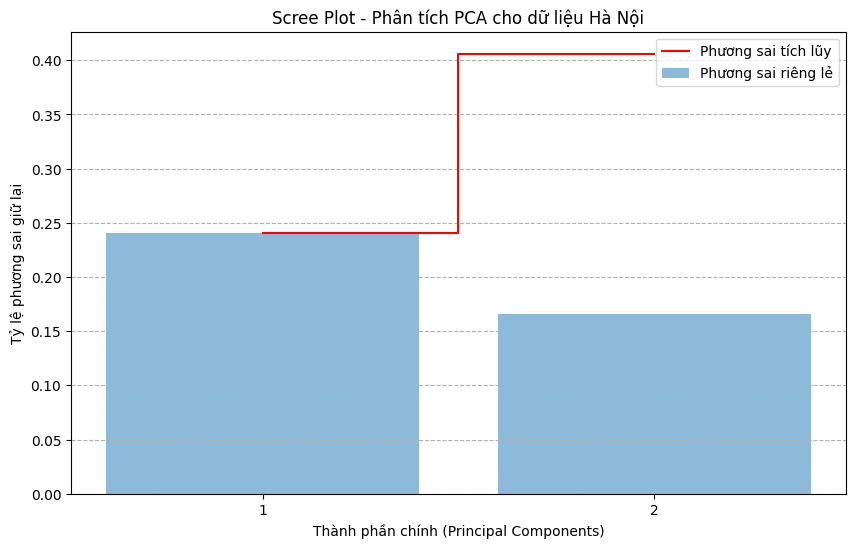

------------------------------
NHẬN XÉT: Sử dụng PCA giúp giảm số biến từ 14 xuống 2 nhưng vẫn giữ được 40.61% lượng thông tin, giúp mô hình chạy nhanh và mượt hơn.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- BƯỚC 1: ĐỌC VÀ GỘP DỮ LIỆU ---
# Đường dẫn tương đối từ folder library_framework ra data_raw
files = ['../data_raw/2022.csv', '../data_raw/2023.csv', '../data_raw/2024.csv']
li = []

for filename in files:
    df_temp = pd.read_csv(filename)
    li.append(df_temp)

df_train = pd.concat(li, axis=0, ignore_index=True)

# --- BƯỚC 2: TIỀN XỬ LÝ (QUAN TRỌNG) ---
# Chỉ lấy các cột chứa số (ví dụ: PM2.5, PM10, AQI...)
X_train = df_train.select_dtypes(include=[np.number])

# Xử lý lỗi NaN: Loại bỏ các dòng trống để PCA không bị lỗi
X_train = X_train.dropna()

print(f"Số lượng mẫu sau khi làm sạch: {X_train.shape[0]}")
print(f"Số lượng biến đầu vào: {X_train.shape[1]}")

# --- BƯỚC 3: CHUẨN HÓA DỮ LIỆU ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# --- BƯỚC 4: THỰC HIỆN PCA ---
# Giảm từ số biến ban đầu xuống 2 thành phần chính
n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# --- BƯỚC 5: VẼ BIỂU ĐỒ SCREE PLOT ---
exp_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_components + 1), exp_var_ratio, alpha=0.5, align='center', label='Phương sai riêng lẻ')
plt.step(range(1, n_components + 1), cum_var_ratio, where='mid', label='Phương sai tích lũy', color='red')

plt.ylabel('Tỷ lệ phương sai giữ lại')
plt.xlabel('Thành phần chính (Principal Components)')
plt.title('Scree Plot - Phân tích PCA cho dữ liệu Hà Nội')
plt.xticks(range(1, n_components + 1))
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--')
plt.show()

# --- BƯỚC 6: NHẬN XÉT ---
info_retained = sum(exp_var_ratio) * 100
print("-" * 30)
print(f"NHẬN XÉT: Sử dụng PCA giúp giảm số biến từ {X_train.shape[1]} xuống {n_components} "
      f"nhưng vẫn giữ được {info_retained:.2f}% lượng thông tin, "
      f"giúp mô hình chạy nhanh và mượt hơn.")